# Running ws_adaptive_mask on my local dataset

My "local dataset" refers to a fused (not deconvolved) dataset of the "karkinos" WT embryo 

## The provided version

In [3]:
from pathlib import Path
import napari 
import sys
import tifffile
from lineagetree import LineageTree, read_from_mastodon
import numpy as np
from skimage.measure import regionprops
import matplotlib.pyplot as plt
from ipywidgets import IntSlider, interactive
from ipywidgets import Layout
import h5py
from scipy.ndimage import gaussian_filter, median_filter, grey_erosion
from skimage.filters import threshold_otsu, sobel
from skimage.segmentation import watershed

# sys.path.append(str(Path.cwd().parent / "src/"))
# #to import scripts from /src, in the parent directory
from watermasks.utils import paths, import_registration_mats_multiview, registered_position_of_id_in_t, paint_annotations
from watermasks.main import ws_adaptive_mask, ws_adaptive_mask_v2

path_h5, path_xml, path_mast, dir_input_images, dir_output_masks = paths()

In [ ]:
# PARAMETERS : CHOOSE TIMEPOINT AND VIEW
TP = 300
VIEW = '0'

# LOAD IMAGE
with h5py.File(path_h5, "r") as f5:
    test_image = f5[f't00{TP}']['s00']['2']['cells'][:]

# # EXPORT THE USED H5 IMAGE (HERE 2ND H5 LAYER) FOR LATER USE AS THE TRAINING STARDIST DATASET
# tifffile.imwrite(dir_input_images+"\\cells_t00300.tif", test_image)
# # run once

# LOAD REG. MATRICES AND LINEAGETREE
R_of_t = import_registration_mats_multiview(path_xml, TP-5,TP+5)
lT = read_from_mastodon(path_mast)

# FIND ASPECT RATIO FOR SCALING
# with h5py.File(path_h5, "r") as f5:
#     test_image_full = f5['t00300']['s00'][VIEW]['cells'][:]
# # don't run this every time

# shape_full_h5 = np.array(np.shape(test_image_full)) 
# #The full image size (0-th level of h5)

# shape_full_h5 = np.array([1188, 992, 1247]) 
# # as measured in (dir = F:)

shape_full_h5 = np.array([300, 1888, 2100])
# as measured in T7_3 data (dir = H:) -> correct file
shape_test_image = np.array(np.shape(test_image))
scaling = shape_test_image/shape_full_h5
# ability to scale between any pare of images
print(f'full image shape = {shape_full_h5}\n2nd h5 layer has shape = {shape_test_image} \n-scaling ratio is [z, y, x] = {scaling}')

# an_space = utils.paint_annotations(lT, t, R_of_t, test_image, scaling, view, 2)

# GET THE REGISTERED MASTODON POSITIONS
reg_pos_at_t = []
for mastodon_id_t in lT.time_nodes[TP]:
    x, y, z = registered_position_of_id_in_t(mastodon_id_t, lT, TP, R_of_t, VIEW, scaling)
    reg_pos_at_t.append([x, y, z])
reg_pos_at_t = np.asarray(reg_pos_at_t)

# USE THE ORIGINAL ADAPTIVE MASK WS
segmentation_image = ws_adaptive_mask(
    test_image,
    reg_pos_at_t)

transformations extracted for all views from xml
full image shape = [ 300 1888 2100]
2nd h5 layer has shape = [300 472 525] 
-scaling ratio is [z, y, x] = [1.   0.25 0.25]
Th 60% – min_intensity=95 – missing seeds: 13
Th 50% – min_intensity=90 – missing seeds: 11
Th 40% – min_intensity=85 – missing seeds: 10
Th 30% – min_intensity=80 – missing seeds: 7
Th 20% – min_intensity=75 – missing seeds: 7
Th 10% – min_intensity=70 – missing seeds: 6
Th 0% – min_intensity=65 – missing seeds: 6


In [ ]:
# VISUALIZE RESULTS
an_space = paint_annotations(TP, lT, shape_test_image,R_of_t,scaling,VIEW,2)
viewer = napari.Viewer()
viewer.add_image(test_image)
viewer.add_image(an_space, colormap='green', opacity=0.70)
viewer.add_labels(segmentation_image[0], opacity=0.70)
napari.run()

# No valid seg. regions

done painting


## ws_adaptive_mask verision : 2 (does not change the main loop, but produces ok-ish results)

In [6]:
# RUN _V2 ON THE DATA
segmentation_image = ws_adaptive_mask_v2(
    test_image,
    reg_pos_at_t)

# VISUALIZE NEW RESULTS
an_space = paint_annotations(TP, lT, shape_test_image,R_of_t,scaling,VIEW,2)
viewer = napari.Viewer()
viewer.add_image(test_image)
viewer.add_image(an_space, colormap='green', opacity=0.70)
viewer.add_labels(segmentation_image[0], opacity=0.70)
napari.run()

Th 60% – min_intensity=95 – missing seeds: 14
Th 50% – min_intensity=90 – missing seeds: 12
Th 40% – min_intensity=85 – missing seeds: 11
Th 30% – min_intensity=80 – missing seeds: 8
Th 20% – min_intensity=75 – missing seeds: 8
Th 10% – min_intensity=70 – missing seeds: 7
Th 0% – min_intensity=65 – missing seeds: 7
done painting


## Discussion

Results with _v2:

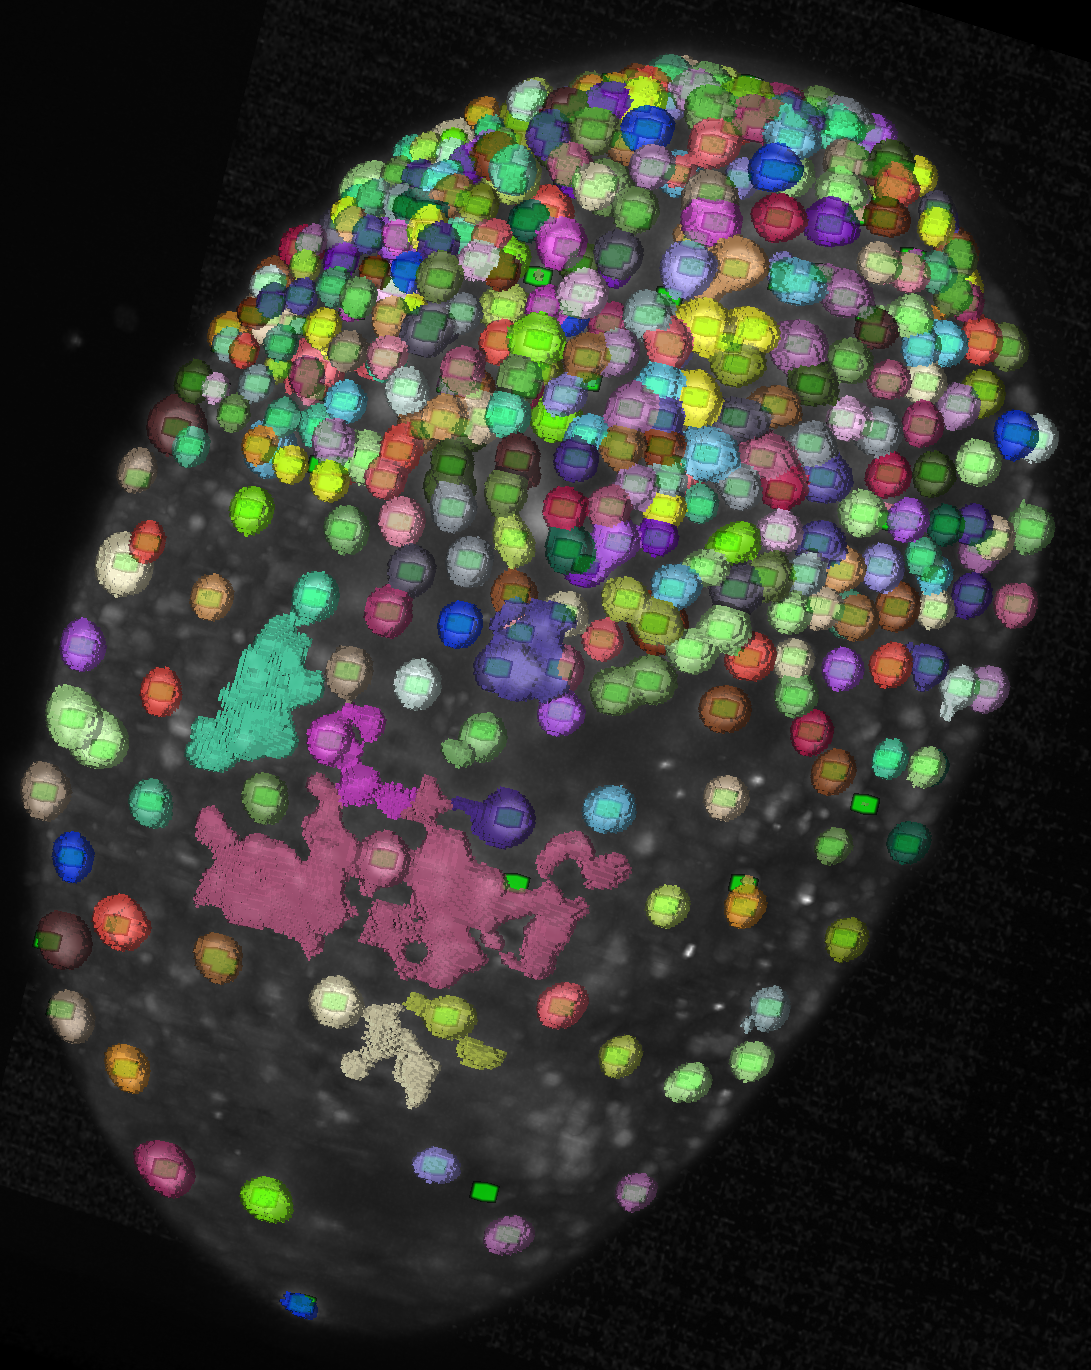

The fact that there is a condition to filter out large regions in the **whlie** loop, but large regions still end up in the final mask, implies that **the code is not working as intended**. We trobleshoot this function in another testing file